**Machine learning** for fast local prediction;
**Probabilistic modeling** for mass-constrained reasoning;
**Deep learning / AI** for sequence-level pattern learning

In [2]:
# Train Path = '/kaggle/input/datasets/gallo33henrique/bioinformatics-protein-dataset-simulated/proteinas_train.csv'
# Test Path = '/kaggle/input/datasets/gallo33henrique/bioinformatics-protein-dataset-simulated/proteinas_test.csv'
# Data Path = '/kaggle/input/datasets/gallo33henrique/bioinformatics-protein-dataset-simulated/proteinas_20000_enriquecido.csv'

In [3]:
# ==============================
# Cell 1: Import Libraries
# ==============================
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.model_selection import train_test_split

In [4]:
# ==============================
# Cell 2: Dataset Paths
# ==============================
TRAIN_PATH = '/kaggle/input/datasets/gallo33henrique/bioinformatics-protein-dataset-simulated/proteinas_train.csv'
TEST_PATH  = '/kaggle/input/datasets/gallo33henrique/bioinformatics-protein-dataset-simulated/proteinas_test.csv'
DATA_PATH  = '/kaggle/input/datasets/gallo33henrique/bioinformatics-protein-dataset-simulated/proteinas_20000_enriquecido.csv'

print("Train exists:", os.path.exists(TRAIN_PATH))
print("Test exists :", os.path.exists(TEST_PATH))
print("Data exists :", os.path.exists(DATA_PATH))

Train exists: True
Test exists : True
Data exists : True


In [5]:
# ==============================
# Cell 3: Load CSV Files
# ==============================
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)
full_df  = pd.read_csv(DATA_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Full shape :", full_df.shape)

Train shape: (16000, 10)
Test shape : (4000, 10)
Full shape : (60000, 10)


In [6]:
# ==============================
# Cell 4: Inspect Dataset
# ==============================
print("Train Columns:\n", train_df.columns.tolist())
print("\nTest Columns:\n", test_df.columns.tolist())
print("\nFull Columns:\n", full_df.columns.tolist())

print("\nTrain Head:")
display(train_df.head())

print("\nTest Head:")
display(test_df.head())

print("\nFull Head:")
display(full_df.head())

Train Columns:
 ['ID_Proteína', 'Sequência', 'Massa_Molecular', 'Ponto_Isoelétrico', 'Hidrofobicidade', 'Carga_Total', 'Proporção_Polar', 'Proporção_Apolar', 'Comprimento_Sequência', 'Classe']

Test Columns:
 ['ID_Proteína', 'Sequência', 'Massa_Molecular', 'Ponto_Isoelétrico', 'Hidrofobicidade', 'Carga_Total', 'Proporção_Polar', 'Proporção_Apolar', 'Comprimento_Sequência', 'Classe']

Full Columns:
 ['ID_Proteína', 'Sequência', 'Massa_Molecular', 'Ponto_Isoelétrico', 'Hidrofobicidade', 'Carga_Total', 'Proporção_Polar', 'Proporção_Apolar', 'Comprimento_Sequência', 'Classe']

Train Head:


,ID_Proteína,Sequência,Massa_Molecular,Ponto_Isoelétrico,Hidrofobicidade,Carga_Total,Proporção_Polar,Proporção_Apolar,Comprimento_Sequência,Classe
0,TRAIN_P00001,GNMRFVLHDEETHWGTLRTTLNCVPSDIYTISGEDSLFWGMAHPFC...,20362.9468,4.866123,0.149425,-3,0.241379,0.408046,174,Estrutural
1,TRAIN_P00002,LFKMQCSFYLLYLAKEAASYQVSMNMLCYEWYNYVYQVTVILRLSR...,9328.7909,6.298636,0.217105,0,0.210526,0.513158,76,Estrutural
2,TRAIN_P00003,PAHLWPYWRFYVWIVFYGYHNPNYHFGMKEVKERPDCKNCTVAVLF...,17616.3852,8.458977,0.192568,8,0.141892,0.466216,148,Estrutural
3,TRAIN_P00004,GEAFSRPHCFACAATKKGFPWARMCCTTSMAMDGVQSKMHKSKHRF...,35244.2968,8.448340,0.160473,21,0.189189,0.408784,296,Estrutural
4,TRAIN_P00005,HYVFQGLMLHCGGYMITACGFGVIFPEQMTREGLIMHTARAHHFLI...,34557.9931,7.696306,0.140411,18,0.202055,0.380137,292,Receptora



Test Head:


,ID_Proteína,Sequência,Massa_Molecular,Ponto_Isoelétrico,Hidrofobicidade,Carga_Total,Proporção_Polar,Proporção_Apolar,Comprimento_Sequência,Classe
0,TEST_P00001,QWPPEVSNGFQSEGKCRWWFIMDPEKPRFHAHAAFHMPDVFRVHYP...,32373.5883,8.466520,0.143657,20,0.167910,0.388060,268,Receptora
1,TEST_P00002,DQGPKNYEYTRQLPCNCCEIMCCDKTNQKSDEVQAAGMTCDKFQHK...,16404.3504,6.558333,0.095070,4,0.225352,0.323944,142,Enzima
2,TEST_P00003,CMAPAVKGESGANKECRPCQDWLYTAPGGMCDICSSTVCCYNYAYE...,19611.2902,7.084207,0.137725,6,0.209581,0.377246,167,Enzima
3,TEST_P00004,KKKHPHILFTFGTMQWIVVKRHAVLMSKVFWRMERQWVNIHYSCDE...,23563.3112,8.716335,0.194301,14,0.181347,0.461140,193,Estrutural
4,TEST_P00005,LMKTRNLLWRGYWWQSPGNLYTFHCDLVCHRFMAPVNFHRECFRTE...,19124.5587,8.398828,0.161491,12,0.285714,0.385093,161,Estrutural



Full Head:


,ID_Proteína,Sequência,Massa_Molecular,Ponto_Isoelétrico,Hidrofobicidade,Carga_Total,Proporção_Polar,Proporção_Apolar,Comprimento_Sequência,Classe
0,P00001,YDRRHIIGFLHFDMQEFITDTAANHTSGSSWEHMELPDTLLPCCEP...,24667.4032,5.655161,0.105263,4,0.210526,0.349282,209,Receptora
1,P00002,CLAIWQQFHNWGDEDLTNTSGNCYSAVCGAWSMEAWNVVCYWGFDL...,21284.0710,5.892805,0.150838,3,0.189944,0.418994,179,Estrutural
2,P00003,QFPGVGNAVQARHMKGTRIHIWIHWARITAIETNQGKNEFPMCTVK...,17255.9747,7.228237,0.171141,9,0.181208,0.422819,149,Enzima
3,P00004,HTHIYATIVTWQCNLTQWELQRGAPNVYNWNSNYGYYVHTGLHWYW...,11792.1909,8.434802,0.173469,7,0.275510,0.408163,98,Transporte
4,P00005,NWFTYSTLKKTYFLSATGCEKGYAYRLTTYTYIAPWSMNPLNTHIE...,22641.7108,7.080968,0.162234,5,0.202128,0.430851,188,Outras


In [7]:
# ==============================
# Cell 5: Missing Values + Data Types
# ==============================
print("=== TRAIN INFO ===")
print(train_df.info())

print("\n=== TEST INFO ===")
print(test_df.info())

print("\n=== FULL INFO ===")
print(full_df.info())

print("\nMissing values in Train:")
print(train_df.isnull().sum())

print("\nMissing values in Test:")
print(test_df.isnull().sum())

print("\nMissing values in Full:")
print(full_df.isnull().sum())

=== TRAIN INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Proteína            16000 non-null  object 
 1   Sequência              16000 non-null  object 
 2   Massa_Molecular        16000 non-null  float64
 3   Ponto_Isoelétrico      16000 non-null  float64
 4   Hidrofobicidade        16000 non-null  float64
 5   Carga_Total            16000 non-null  int64  
 6   Proporção_Polar        16000 non-null  float64
 7   Proporção_Apolar       16000 non-null  float64
 8   Comprimento_Sequência  16000 non-null  int64  
 9   Classe                 16000 non-null  object 
dtypes: float64(5), int64(2), object(3)
memory usage: 1.2+ MB
None

=== TEST INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---

In [8]:
# ==============================
# Cell 6 (FIXED): Detect Sequence Column
# ==============================

print("All columns:\n", full_df.columns.tolist())

# Try to find sequence column candidates
possible_seq_cols = [col for col in full_df.columns if any(
    key in col.lower() for key in ['seq', 'sequence', 'protein']
)]

print("\nPossible sequence columns:", possible_seq_cols)

# Auto-select if possible
if len(possible_seq_cols) >= 1:
    SEQ_COL = possible_seq_cols[0]   # pick first candidate
    print("Using sequence column:", SEQ_COL)
else:
    print("❌ No sequence column detected. Please check manually.")

All columns:
 ['ID_Proteína', 'Sequência', 'Massa_Molecular', 'Ponto_Isoelétrico', 'Hidrofobicidade', 'Carga_Total', 'Proporção_Polar', 'Proporção_Apolar', 'Comprimento_Sequência', 'Classe']

Possible sequence columns: ['Sequência', 'Comprimento_Sequência']
Using sequence column: Sequência


In [9]:
# ==============================
# Cell 7: Sequence Quality Check
# ==============================
AMINO_ACIDS = set(list("ACDEFGHIKLMNPQRSTVWY"))

def check_sequence(seq):
    seq = str(seq).strip()
    invalid_chars = sorted(list(set(seq) - AMINO_ACIDS))
    return len(seq), invalid_chars

# preview first 10 sequences
for i, seq in enumerate(full_df[SEQ_COL].head(10)):
    length, invalid = check_sequence(seq)
    print(f"Row {i}: Length={length}, Invalid chars={invalid}")

Row 0: Length=209, Invalid chars=[]
Row 1: Length=179, Invalid chars=[]
Row 2: Length=149, Invalid chars=[]
Row 3: Length=98, Invalid chars=[]
Row 4: Length=188, Invalid chars=[]
Row 5: Length=253, Invalid chars=[]
Row 6: Length=154, Invalid chars=[]
Row 7: Length=128, Invalid chars=[]
Row 8: Length=273, Invalid chars=[]
Row 9: Length=117, Invalid chars=[]


In [10]:
# ==============================
# Cell 8: Add Sequence Length
# ==============================
train_df['seq_length'] = train_df[SEQ_COL].astype(str).apply(len)
test_df['seq_length']  = test_df[SEQ_COL].astype(str).apply(len)
full_df['seq_length']  = full_df[SEQ_COL].astype(str).apply(len)

print(train_df['seq_length'].describe())

count    16000.000000
mean       174.033688
std         72.920304
min         50.000000
25%        111.000000
50%        173.000000
75%        237.000000
max        300.000000
Name: seq_length, dtype: float64


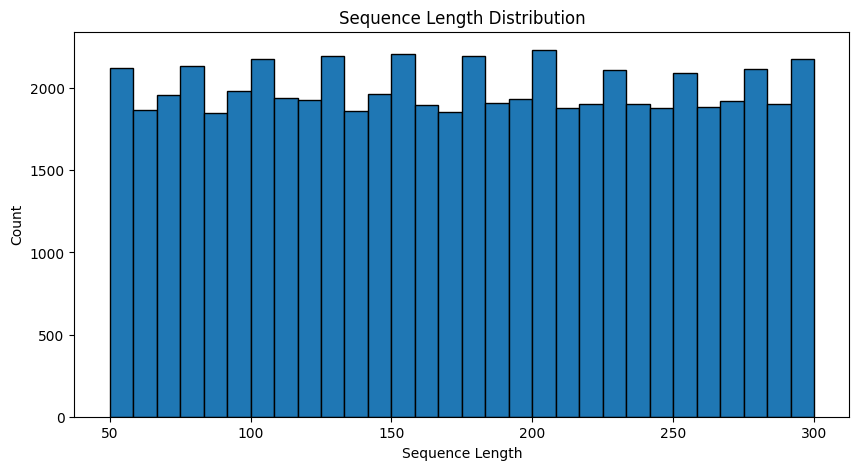

In [11]:
# ==============================
# Cell 9: Sequence Length Distribution
# ==============================
plt.figure(figsize=(10, 5))
plt.hist(full_df['seq_length'], bins=30, edgecolor='black')
plt.title("Sequence Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.show()

In [12]:
# ==============================
# Cell 10: Clean Sequences
# ==============================
def is_valid_protein(seq):
    seq = str(seq).strip()
    return len(seq) > 0 and all(ch in AMINO_ACIDS for ch in seq)

train_df = train_df[train_df[SEQ_COL].astype(str).apply(is_valid_protein)].reset_index(drop=True)
test_df  = test_df[test_df[SEQ_COL].astype(str).apply(is_valid_protein)].reset_index(drop=True)
full_df  = full_df[full_df[SEQ_COL].astype(str).apply(is_valid_protein)].reset_index(drop=True)

print("Cleaned Train shape:", train_df.shape)
print("Cleaned Test shape :", test_df.shape)
print("Cleaned Full shape :", full_df.shape)

Cleaned Train shape: (16000, 11)
Cleaned Test shape : (4000, 11)
Cleaned Full shape : (60000, 11)


In [13]:
# ==============================
# Cell 11: Detect Label Columns
# ==============================
possible_label_cols = [col for col in full_df.columns if any(
    key in col.lower() for key in ['class', 'label', 'target', 'family', 'type']
)]
print("Possible label columns:", possible_label_cols)

for col in possible_label_cols:
    print(f"\nColumn: {col}")
    print(full_df[col].value_counts().head(20))

Possible label columns: ['Classe']

Column: Classe
Classe
Outras        12216
Estrutural    11991
Transporte    11989
Enzima        11954
Receptora     11850
Name: count, dtype: int64


In [14]:
# ==============================
# Cell 12: Final Prepared Data Preview
# ==============================
display(full_df.head())
print("Final columns:", full_df.columns.tolist())
print("Sequence column used:", SEQ_COL)

,ID_Proteína,Sequência,Massa_Molecular,Ponto_Isoelétrico,Hidrofobicidade,Carga_Total,Proporção_Polar,Proporção_Apolar,Comprimento_Sequência,Classe,seq_length
0,P00001,YDRRHIIGFLHFDMQEFITDTAANHTSGSSWEHMELPDTLLPCCEP...,24667.4032,5.655161,0.105263,4,0.210526,0.349282,209,Receptora,209
1,P00002,CLAIWQQFHNWGDEDLTNTSGNCYSAVCGAWSMEAWNVVCYWGFDL...,21284.0710,5.892805,0.150838,3,0.189944,0.418994,179,Estrutural,179
2,P00003,QFPGVGNAVQARHMKGTRIHIWIHWARITAIETNQGKNEFPMCTVK...,17255.9747,7.228237,0.171141,9,0.181208,0.422819,149,Enzima,149
3,P00004,HTHIYATIVTWQCNLTQWELQRGAPNVYNWNSNYGYYVHTGLHWYW...,11792.1909,8.434802,0.173469,7,0.275510,0.408163,98,Transporte,98
4,P00005,NWFTYSTLKKTYFLSATGCEKGYAYRLTTYTYIAPWSMNPLNTHIE...,22641.7108,7.080968,0.162234,5,0.202128,0.430851,188,Outras,188


Final columns: ['ID_Proteína', 'Sequência', 'Massa_Molecular', 'Ponto_Isoelétrico', 'Hidrofobicidade', 'Carga_Total', 'Proporção_Polar', 'Proporção_Apolar', 'Comprimento_Sequência', 'Classe', 'seq_length']
Sequence column used: Sequência


Phase 2 — Scaffold / Gap Dataset Generation

In [15]:
# ==============================
# Cell 13: Reproducibility + Config
# ==============================
random.seed(42)
np.random.seed(42)

SEQ_COL = 'Sequência'
ID_COL = 'ID_Proteína'
LABEL_COL = 'Classe'

AMINO_ACID_MASS = {
    'A': 71.03711, 'C': 103.00919, 'D': 115.02694, 'E': 129.04259,
    'F': 147.06841, 'G': 57.02146, 'H': 137.05891, 'I': 113.08406,
    'K': 128.09496, 'L': 113.08406, 'M': 131.04049, 'N': 114.04293,
    'P': 97.05276, 'Q': 128.05858, 'R': 156.10111, 'S': 87.03203,
    'T': 101.04768, 'V': 99.06841, 'W': 186.07931, 'Y': 163.06333
}

MIN_SEQ_LEN = 30   # keep enough room for context + gap
print("Config loaded.")

Config loaded.


In [16]:
# ==============================
# Cell 14: Filter Usable Sequences
# ==============================
usable_train_df = train_df[train_df['seq_length'] >= MIN_SEQ_LEN].copy().reset_index(drop=True)
usable_test_df  = test_df[test_df['seq_length'] >= MIN_SEQ_LEN].copy().reset_index(drop=True)

print("Usable Train shape:", usable_train_df.shape)
print("Usable Test shape :", usable_test_df.shape)

Usable Train shape: (16000, 11)
Usable Test shape : (4000, 11)


In [17]:
# ==============================
# Cell 15: Helper Functions
# ==============================
def peptide_mass(seq):
    """Compute total peptide mass of a sequence."""
    return round(sum(AMINO_ACID_MASS.get(aa, 0.0) for aa in seq), 4)

def create_gap_sample(sequence, protein_id=None, label=None,
                      min_gap=3, max_gap=12, context_k=11):
    """
    Create one gap sample from a full protein sequence.
    Returns a dict for known-gap-size and known-gap-mass tasks.
    """
    sequence = str(sequence).strip()
    seq_len = len(sequence)

    # must have enough length for left context + gap + right context
    min_required = (2 * context_k) + min_gap
    if seq_len < min_required:
        return None

    gap_len = random.randint(min_gap, min(max_gap, seq_len - (2 * context_k)))
    start_min = context_k
    start_max = seq_len - context_k - gap_len

    if start_max <= start_min:
        return None

    gap_start = random.randint(start_min, start_max)
    gap_end = gap_start + gap_len

    left_context = sequence[max(0, gap_start - context_k):gap_start]
    right_context = sequence[gap_end:min(seq_len, gap_end + context_k)]
    gap_seq = sequence[gap_start:gap_end]

    scaffold_known_size = sequence[:gap_start] + ("-" * gap_len) + sequence[gap_end:]
    scaffold_known_mass = sequence[:gap_start] + f"[MASS_{peptide_mass(gap_seq)}]" + sequence[gap_end:]

    return {
        "protein_id": protein_id,
        "class_label": label,
        "full_sequence": sequence,
        "seq_length": seq_len,
        "gap_start": gap_start,
        "gap_end": gap_end,
        "gap_size": gap_len,
        "gap_sequence": gap_seq,
        "gap_mass": peptide_mass(gap_seq),
        "left_context": left_context,
        "right_context": right_context,
        "scaffold_known_size": scaffold_known_size,
        "scaffold_known_mass": scaffold_known_mass
    }

In [18]:
# ==============================
# Cell 16: Create Initial Scaffold Datasets
# ==============================
known_gap_train_samples = []
known_gap_test_samples = []

for _, row in usable_train_df.iterrows():
    sample = create_gap_sample(
        sequence=row[SEQ_COL],
        protein_id=row[ID_COL],
        label=row[LABEL_COL],
        min_gap=3,
        max_gap=12,
        context_k=11
    )
    if sample is not None:
        known_gap_train_samples.append(sample)

for _, row in usable_test_df.iterrows():
    sample = create_gap_sample(
        sequence=row[SEQ_COL],
        protein_id=row[ID_COL],
        label=row[LABEL_COL],
        min_gap=3,
        max_gap=12,
        context_k=11
    )
    if sample is not None:
        known_gap_test_samples.append(sample)

known_gap_train_df = pd.DataFrame(known_gap_train_samples)
known_gap_test_df = pd.DataFrame(known_gap_test_samples)

print("Known-gap Train shape:", known_gap_train_df.shape)
print("Known-gap Test shape :", known_gap_test_df.shape)

Known-gap Train shape: (16000, 13)
Known-gap Test shape : (4000, 13)


In [19]:
# ==============================
# Cell 17: Inspect Scaffold Samples
# ==============================
display(known_gap_train_df.head())

print("\nColumns:")
print(known_gap_train_df.columns.tolist())

,protein_id,class_label,full_sequence,seq_length,gap_start,gap_end,gap_size,gap_sequence,gap_mass,left_context,right_context,scaffold_known_size,scaffold_known_mass
0,TRAIN_P00001,Estrutural,GNMRFVLHDEETHWGTLRTTLNCVPSDIYTISGEDSLFWGMAHPFC...,174,17,21,4,RTTL,471.2805,LHDEETHWGTL,NCVPSDIYTIS,GNMRFVLHDEETHWGTL----NCVPSDIYTISGEDSLFWGMAHPFC...,GNMRFVLHDEETHWGTL[MASS_471.2805]NCVPSDIYTISGED...
1,TRAIN_P00002,Estrutural,LFKMQCSFYLLYLAKEAASYQVSMNMLCYEWYNYVYQVTVILRLSR...,76,26,33,7,LCYEWYN,971.3847,EAASYQVSMNM,YVYQVTVILRL,LFKMQCSFYLLYLAKEAASYQVSMNM-------YVYQVTVILRLSR...,LFKMQCSFYLLYLAKEAASYQVSMNM[MASS_971.3847]YVYQV...
2,TRAIN_P00003,Estrutural,PAHLWPYWRFYVWIVFYGYHNPNYHFGMKEVKERPDCKNCTVAVLF...,148,28,34,6,KEVKER,769.4446,GYHNPNYHFGM,PDCKNCTVAVL,PAHLWPYWRFYVWIVFYGYHNPNYHFGM------PDCKNCTVAVLF...,PAHLWPYWRFYVWIVFYGYHNPNYHFGM[MASS_769.4446]PDC...
3,TRAIN_P00004,Estrutural,GEAFSRPHCFACAATKKGFPWARMCCTTSMAMDGVQSKMHKSKHRF...,296,55,59,4,DCTY,482.1471,RFVKWFDCYGS,KWHSDIHGSWS,GEAFSRPHCFACAATKKGFPWARMCCTTSMAMDGVQSKMHKSKHRF...,GEAFSRPHCFACAATKKGFPWARMCCTTSMAMDGVQSKMHKSKHRF...
4,TRAIN_P00005,Receptora,HYVFQGLMLHCGGYMITACGFGVIFPEQMTREGLIMHTARAHHFLI...,292,227,239,12,KFTHTWDFCWDY,1629.6711,KGHPASFEAYQ,SLYTWWPYMER,HYVFQGLMLHCGGYMITACGFGVIFPEQMTREGLIMHTARAHHFLI...,HYVFQGLMLHCGGYMITACGFGVIFPEQMTREGLIMHTARAHHFLI...



Columns:
['protein_id', 'class_label', 'full_sequence', 'seq_length', 'gap_start', 'gap_end', 'gap_size', 'gap_sequence', 'gap_mass', 'left_context', 'right_context', 'scaffold_known_size', 'scaffold_known_mass']


In [20]:
# ==============================
# Cell 18: Visual Check of Samples
# ==============================
for i in range(3):
    row = known_gap_train_df.iloc[i]
    print(f"\nSample {i+1}")
    print("Protein ID        :", row["protein_id"])
    print("Class             :", row["class_label"])
    print("Gap Size          :", row["gap_size"])
    print("Gap Sequence      :", row["gap_sequence"])
    print("Gap Mass          :", row["gap_mass"])
    print("Left Context      :", row["left_context"])
    print("Right Context     :", row["right_context"])
    print("Known Size Scaffold:", row["scaffold_known_size"][:120], "...")
    print("Known Mass Scaffold:", row["scaffold_known_mass"][:120], "...")


Sample 1
Protein ID        : TRAIN_P00001
Class             : Estrutural
Gap Size          : 4
Gap Sequence      : RTTL
Gap Mass          : 471.2805
Left Context      : LHDEETHWGTL
Right Context     : NCVPSDIYTIS
Known Size Scaffold: GNMRFVLHDEETHWGTL----NCVPSDIYTISGEDSLFWGMAHPFCYPGSKRTMHPMWQSSDDCANCGTYWMGWDSPIQETEYRWMMDWITMESDALAGRNCCVMNMDWVRSCSSWTHIK ...
Known Mass Scaffold: GNMRFVLHDEETHWGTL[MASS_471.2805]NCVPSDIYTISGEDSLFWGMAHPFCYPGSKRTMHPMWQSSDDCANCGTYWMGWDSPIQETEYRWMMDWITMESDALAGRNCCVMNMDW ...

Sample 2
Protein ID        : TRAIN_P00002
Class             : Estrutural
Gap Size          : 7
Gap Sequence      : LCYEWYN
Gap Mass          : 971.3847
Left Context      : EAASYQVSMNM
Right Context     : YVYQVTVILRL
Known Size Scaffold: LFKMQCSFYLLYLAKEAASYQVSMNM-------YVYQVTVILRLSREWCPVCTYCYWFVERRVWTTDSTEACCFNC ...
Known Mass Scaffold: LFKMQCSFYLLYLAKEAASYQVSMNM[MASS_971.3847]YVYQVTVILRLSREWCPVCTYCYWFVERRVWTTDSTEACCFNC ...

Sample 3
Protein ID        : TRAIN_P00003
Class             : Es

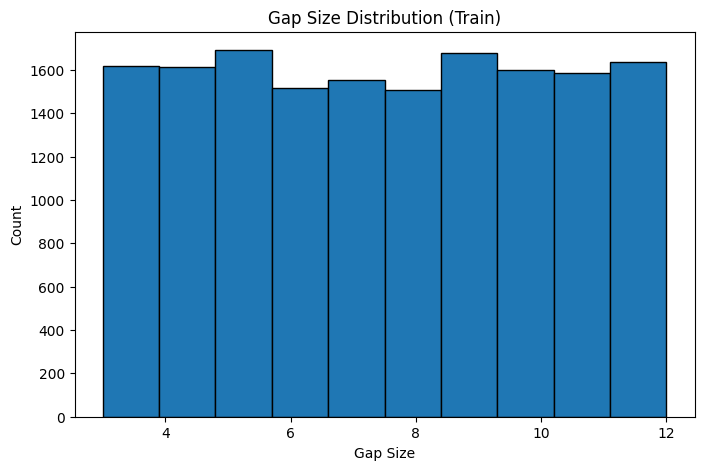

In [21]:
# ==============================
# Cell 19: Gap Size Distribution
# ==============================
plt.figure(figsize=(8, 5))
plt.hist(known_gap_train_df["gap_size"], bins=10, edgecolor="black")
plt.title("Gap Size Distribution (Train)")
plt.xlabel("Gap Size")
plt.ylabel("Count")
plt.show()

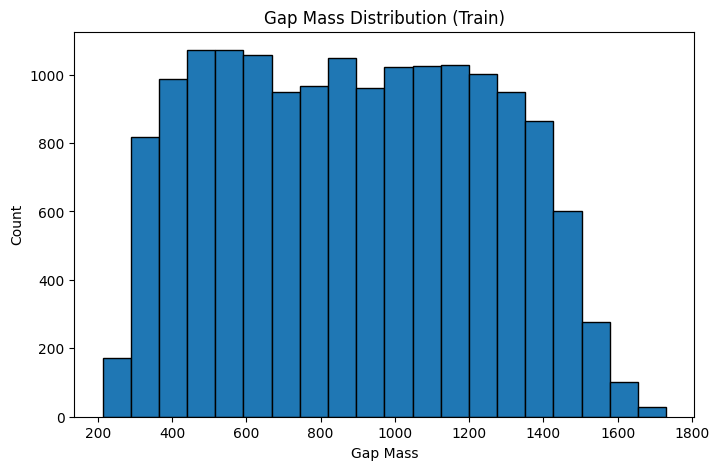

In [22]:
# ==============================
# Cell 20: Gap Mass Distribution
# ==============================
plt.figure(figsize=(8, 5))
plt.hist(known_gap_train_df["gap_mass"], bins=20, edgecolor="black")
plt.title("Gap Mass Distribution (Train)")
plt.xlabel("Gap Mass")
plt.ylabel("Count")
plt.show()

In [23]:
# ==============================
# Cell 21: Save Generated Scaffold Data
# ==============================
known_gap_train_df.to_csv("/kaggle/working/known_gap_train.csv", index=False)
known_gap_test_df.to_csv("/kaggle/working/known_gap_test.csv", index=False)

print("Saved:")
print("/kaggle/working/known_gap_train.csv")
print("/kaggle/working/known_gap_test.csv")

Saved:
/kaggle/working/known_gap_train.csv
/kaggle/working/known_gap_test.csv


In [24]:
# ==============================
# Cell 22: Assign Difficulty Levels
# ==============================
def assign_gap_difficulty(gap_size):
    if gap_size <= 4:
        return "small"
    elif gap_size <= 8:
        return "medium"
    else:
        return "large"

known_gap_train_df["gap_difficulty"] = known_gap_train_df["gap_size"].apply(assign_gap_difficulty)
known_gap_test_df["gap_difficulty"] = known_gap_test_df["gap_size"].apply(assign_gap_difficulty)

print(known_gap_train_df["gap_difficulty"].value_counts())

gap_difficulty
large     6499
medium    6272
small     3229
Name: count, dtype: int64


In [25]:
# ==============================
# Cell 23: Class vs Difficulty
# ==============================
difficulty_table = pd.crosstab(known_gap_train_df["class_label"], known_gap_train_df["gap_difficulty"])
display(difficulty_table)

gap_difficulty,large,medium,small
class_label,,,
Enzima,1260,1305,670
Estrutural,1308,1277,647
Outras,1278,1248,657
Receptora,1319,1207,599
Transporte,1334,1235,656


Phase 3 — Preprocessing for Modeling

Now we will prepare data for:

Machine Learning (known gap size)
Deep Learning (sequence prediction)
Probabilistic model (mass-based later)

In [26]:
# ==============================
# Cell 24: Amino Acid Encoding
# ==============================
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

aa_to_idx = {aa: i+1 for i, aa in enumerate(AMINO_ACIDS)}  # start from 1
aa_to_idx["PAD"] = 0

idx_to_aa = {v: k for k, v in aa_to_idx.items()}

print("Encoding size:", len(aa_to_idx))
print(aa_to_idx)

Encoding size: 21
{'A': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'K': 9, 'L': 10, 'M': 11, 'N': 12, 'P': 13, 'Q': 14, 'R': 15, 'S': 16, 'T': 17, 'V': 18, 'W': 19, 'Y': 20, 'PAD': 0}


In [27]:
# ==============================
# Cell 25: Encoding Function
# ==============================
def encode_sequence(seq, max_len):
    seq = str(seq)
    encoded = [aa_to_idx.get(aa, 0) for aa in seq]
    
    if len(encoded) < max_len:
        encoded += [0] * (max_len - len(encoded))
    else:
        encoded = encoded[:max_len]
        
    return encoded

In [28]:
# ==============================
# Cell 26: Prepare ML Dataset
# ==============================
MAX_CONTEXT = 11

X = []
y = []

for _, row in known_gap_train_df.iterrows():
    
    left = row["left_context"]
    right = row["right_context"]
    gap_seq = row["gap_sequence"]
    
    # input = left + right
    combined = left + right
    
    encoded_input = encode_sequence(combined, max_len=MAX_CONTEXT*2)
    
    # target = first amino acid of gap
    target_aa = gap_seq[0]
    target = aa_to_idx[target_aa]
    
    X.append(encoded_input)
    y.append(target)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (16000, 22)
y shape: (16000,)


In [29]:
# ==============================
# Cell 27: Train-Val Split
# ==============================
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)

Train: (12800, 22)
Val  : (3200, 22)


In [30]:
# ==============================
# Cell 28: Random Forest Model
# ==============================
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Model trained.")

Model trained.


In [31]:
# ==============================
# Cell 29: Evaluation
# ==============================
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf_model.predict(X_val)

acc = accuracy_score(y_val, y_pred)
print("Validation Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Validation Accuracy: 0.0496875

Classification Report:
              precision    recall  f1-score   support

           1       0.07      0.08      0.08       178
           2       0.02      0.02      0.02       147
           3       0.04      0.04      0.04       158
           4       0.01      0.01      0.01       138
           5       0.05      0.05      0.05       153
           6       0.06      0.08      0.07       155
           7       0.06      0.05      0.05       146
           8       0.07      0.07      0.07       190
           9       0.04      0.03      0.04       182
          10       0.04      0.04      0.04       165
          11       0.04      0.04      0.04       184
          12       0.07      0.06      0.06       155
          13       0.06      0.05      0.05       144
          14       0.04      0.04      0.04       172
          15       0.05      0.04      0.05       178
          16       0.04      0.04      0.04       137
          17       0.04   

In [32]:
# ==============================
# Cell 30: Sample Predictions
# ==============================
for i in range(5):
    pred_idx = y_pred[i]
    true_idx = y_val[i]
    
    print(f"Sample {i+1}")
    print("Predicted:", idx_to_aa[pred_idx])
    print("Actual   :", idx_to_aa[true_idx])
    print("---")

Sample 1
Predicted: T
Actual   : V
---
Sample 2
Predicted: A
Actual   : I
---
Sample 3
Predicted: P
Actual   : R
---
Sample 4
Predicted: L
Actual   : C
---
Sample 5
Predicted: L
Actual   : L
---


Phase 4 — Improved Feature Engineering + Better ML

We will improve performance using:

Add physicochemical features
Add gap size info
Add position info
Add statistical features

In [33]:
# ==============================
# Cell 31: Feature Engineering
# ==============================
def extract_features(row):
    left = row["left_context"]
    right = row["right_context"]
    
    features = {}
    
    # Length features
    features["gap_size"] = row["gap_size"]
    features["gap_mass"] = row["gap_mass"]
    features["seq_length"] = row["seq_length"]
    
    # Composition features
    full = left + right
    counts = Counter(full)
    
    for aa in AMINO_ACIDS:
        features[f"count_{aa}"] = counts.get(aa, 0)
    
    # Hydrophobic ratio (simple)
    hydrophobic = set("AILMFWYV")
    features["hydrophobic_ratio"] = sum(1 for aa in full if aa in hydrophobic) / len(full)
    
    return features

In [34]:
# ==============================
# Cell 32: Build Feature Matrix
# ==============================
feature_list = []

for _, row in known_gap_train_df.iterrows():
    feature_list.append(extract_features(row))

feature_df = pd.DataFrame(feature_list)

print("Feature shape:", feature_df.shape)
display(feature_df.head())

Feature shape: (16000, 24)


,gap_size,gap_mass,seq_length,count_A,count_C,count_D,count_E,count_F,count_G,count_H,...,count_N,count_P,count_Q,count_R,count_S,count_T,count_V,count_W,count_Y,hydrophobic_ratio
0,4,471.2805,174,0,1,2,2,0,1,2,...,1,1,0,0,2,3,1,1,1,0.318182
1,7,971.3847,76,2,0,0,1,0,0,0,...,1,0,2,1,2,1,4,0,3,0.636364
2,6,769.4446,148,1,2,1,0,1,2,2,...,3,2,0,0,0,1,2,0,2,0.363636
3,4,482.1471,296,0,1,2,0,2,2,2,...,0,0,0,1,4,0,1,3,1,0.363636
4,12,1629.6711,292,2,0,0,2,1,1,1,...,0,2,1,1,2,1,0,2,3,0.454545


In [35]:
# ==============================
# Cell 33: Combine Features
# ==============================
X_combined = np.concatenate([X, feature_df.values], axis=1)

print("New X shape:", X_combined.shape)

New X shape: (16000, 46)


In [36]:
# ==============================
# Cell 34: Train-Val Split
# ==============================
X_train, X_val, y_train, y_val = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)

In [37]:
# ==============================
# Cell 35: Improved RF Model
# ==============================
rf_model2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    random_state=42,
    n_jobs=-1
)

rf_model2.fit(X_train, y_train)

print("Improved model trained.")

Improved model trained.


In [38]:
# ==============================
# Cell 36: Evaluation
# ==============================
y_pred = rf_model2.predict(X_val)

acc = accuracy_score(y_val, y_pred)
print("Validation Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Validation Accuracy: 0.0628125

Classification Report:
              precision    recall  f1-score   support

           1       0.08      0.08      0.08       178
           2       0.06      0.05      0.05       147
           3       0.08      0.07      0.08       158
           4       0.06      0.08      0.07       138
           5       0.04      0.03      0.04       153
           6       0.09      0.14      0.11       155
           7       0.03      0.02      0.02       146
           8       0.06      0.06      0.06       190
           9       0.06      0.05      0.05       182
          10       0.06      0.06      0.06       165
          11       0.04      0.04      0.04       184
          12       0.05      0.04      0.04       155
          13       0.11      0.08      0.09       144
          14       0.04      0.03      0.04       172
          15       0.08      0.06      0.07       178
          16       0.04      0.04      0.04       137
          17       0.02   

In [39]:
# ==============================
# Cell 37: PyTorch Setup
# ==============================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [40]:
# ==============================
# Cell 38: Build DL Dataset
# ==============================
MAX_CONTEXT = 11
MAX_GAP = 12

class ProteinGapDataset(Dataset):
    def __init__(self, df):
        self.samples = []
        
        for _, row in df.iterrows():
            left = row["left_context"]
            right = row["right_context"]
            gap = row["gap_sequence"]
            
            input_seq = left + right
            input_encoded = encode_sequence(input_seq, MAX_CONTEXT*2)
            
            gap_encoded = encode_sequence(gap, MAX_GAP)
            
            self.samples.append((input_encoded, gap_encoded))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        x, y = self.samples[idx]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

train_dataset = ProteinGapDataset(known_gap_train_df)
val_dataset   = ProteinGapDataset(known_gap_test_df)

print("Dataset ready.")

Dataset ready.


In [41]:
# ==============================
# Cell 39: DataLoader
# ==============================
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)

print("DataLoader ready.")

DataLoader ready.


In [42]:
# ==============================
# Cell 40: Fixed Gap Predictor
# ==============================
class GapPredictor(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, max_gap=12):
        super().__init__()
        
        self.max_gap = max_gap
        self.vocab_size = vocab_size
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        
        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        
        # output for all gap positions together
        self.fc2 = nn.Linear(hidden_dim, max_gap * vocab_size)
    
    def forward(self, x):
        x = self.embedding(x)                     # (B, 22, embed_dim)
        out, (h_n, c_n) = self.lstm(x)           # h_n: (2, B, hidden_dim) because bidirectional
        
        # concatenate last hidden states from both directions
        h_forward = h_n[0]                       # (B, hidden_dim)
        h_backward = h_n[1]                      # (B, hidden_dim)
        h = torch.cat([h_forward, h_backward], dim=1)   # (B, hidden_dim*2)
        
        h = self.fc1(h)
        h = self.relu(h)
        h = self.dropout(h)
        
        out = self.fc2(h)                        # (B, max_gap * vocab_size)
        out = out.view(-1, self.max_gap, self.vocab_size)  # (B, 12, vocab_size)
        return out

vocab_size = len(aa_to_idx)
model = GapPredictor(vocab_size=vocab_size, max_gap=MAX_GAP).to(device)

print(model)

GapPredictor(
  (embedding): Embedding(21, 64, padding_idx=0)
  (lstm): LSTM(64, 128, batch_first=True, bidirectional=True)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=252, bias=True)
)


In [43]:
# ==============================
# Cell 41: Training Setup
# ==============================
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [44]:
# ==============================
# Cell 42: Fixed Training Loop
# ==============================
EPOCHS = 50

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    
    for x, y in train_loader:
        x = x.to(device)   # (B, 22)
        y = y.to(device)   # (B, 12)
        
        optimizer.zero_grad()
        
        outputs = model(x)                  # (B, 12, vocab_size)
        outputs = outputs.view(-1, vocab_size)   # (B*12, vocab_size)
        y = y.view(-1)                           # (B*12)
        
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")

Epoch 1/50, Loss: 3.0128
Epoch 2/50, Loss: 2.9986
Epoch 3/50, Loss: 2.9911
Epoch 4/50, Loss: 2.9806
Epoch 5/50, Loss: 2.9658
Epoch 6/50, Loss: 2.9450
Epoch 7/50, Loss: 2.9201
Epoch 8/50, Loss: 2.8894
Epoch 9/50, Loss: 2.8567
Epoch 10/50, Loss: 2.8216
Epoch 11/50, Loss: 2.7863
Epoch 12/50, Loss: 2.7503
Epoch 13/50, Loss: 2.7141
Epoch 14/50, Loss: 2.6780
Epoch 15/50, Loss: 2.6432
Epoch 16/50, Loss: 2.6111
Epoch 17/50, Loss: 2.5779
Epoch 18/50, Loss: 2.5489
Epoch 19/50, Loss: 2.5187
Epoch 20/50, Loss: 2.4858
Epoch 21/50, Loss: 2.4604
Epoch 22/50, Loss: 2.4360
Epoch 23/50, Loss: 2.4102
Epoch 24/50, Loss: 2.3850
Epoch 25/50, Loss: 2.3625
Epoch 26/50, Loss: 2.3417
Epoch 27/50, Loss: 2.3166
Epoch 28/50, Loss: 2.3023
Epoch 29/50, Loss: 2.2801
Epoch 30/50, Loss: 2.2630
Epoch 31/50, Loss: 2.2426
Epoch 32/50, Loss: 2.2288
Epoch 33/50, Loss: 2.2113
Epoch 34/50, Loss: 2.1928
Epoch 35/50, Loss: 2.1785
Epoch 36/50, Loss: 2.1641
Epoch 37/50, Loss: 2.1514
Epoch 38/50, Loss: 2.1378
Epoch 39/50, Loss: 2.

In [45]:
# ==============================
# Cell 43: Validation
# ==============================
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        y = y.to(device)
        
        outputs = model(x)                         # (B, 12, vocab_size)
        preds = torch.argmax(outputs, dim=-1)     # (B, 12)
        
        mask = (y != 0)
        correct += (preds[mask] == y[mask]).sum().item()
        total += mask.sum().item()

token_accuracy = correct / total
print("Token-level Validation Accuracy:", token_accuracy)

Token-level Validation Accuracy: 0.04812441596582566


In [46]:
# ==============================
# Cell 44: Sample Gap Predictions
# ==============================
def decode_sequence(indices):
    chars = []
    for idx in indices:
        aa = idx_to_aa.get(int(idx), "")
        if aa != "PAD":
            chars.append(aa)
    return "".join(chars)

model.eval()

x_batch, y_batch = next(iter(val_loader))
x_batch = x_batch.to(device)

with torch.no_grad():
    outputs = model(x_batch)
    preds = torch.argmax(outputs, dim=-1).cpu().numpy()

y_true = y_batch.numpy()

for i in range(5):
    true_gap = decode_sequence(y_true[i])
    pred_gap = decode_sequence(preds[i])
    
    print(f"Sample {i+1}")
    print("True Gap :", true_gap)
    print("Pred Gap :", pred_gap)
    print("---")

Sample 1
True Gap : NDHAHWSGWLN
Pred Gap : VANIMQHTRHTT
---
Sample 2
True Gap : HAPQAA
Pred Gap : MVTCKRQPHLVC
---
Sample 3
True Gap : FYSYKCSCEKLT
Pred Gap : CHFNPEFCWVDG
---
Sample 4
True Gap : WVNIH
Pred Gap : QCVKKLEFGKWC
---
Sample 5
True Gap : TLTYVSVANNAS
Pred Gap : DADVDDRMKVPI
---


In [47]:
# ==============================
# Cell 45: Exact Match Evaluation
# ==============================
def decode_sequence(indices):
    chars = []
    for idx in indices:
        aa = idx_to_aa.get(int(idx), "")
        if aa != "PAD":
            chars.append(aa)
    return "".join(chars)

model.eval()

all_true = []
all_pred = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        outputs = model(x)
        preds = torch.argmax(outputs, dim=-1).cpu().numpy()
        y = y.numpy()
        
        for i in range(len(y)):
            true_gap = decode_sequence(y[i])
            pred_gap = decode_sequence(preds[i])
            all_true.append(true_gap)
            all_pred.append(pred_gap)

exact_match = np.mean([t == p for t, p in zip(all_true, all_pred)])
print("Exact Match Accuracy:", exact_match)

Exact Match Accuracy: 0.0


In [48]:
# ==============================
# Cell 46: Evaluate by Gap Length
# ==============================
val_gap_sizes = known_gap_test_df["gap_size"].tolist()

eval_df = pd.DataFrame({
    "true_gap": all_true,
    "pred_gap": all_pred,
    "gap_size": val_gap_sizes
})

eval_df["exact_match"] = (eval_df["true_gap"] == eval_df["pred_gap"]).astype(int)

def residue_accuracy(true_seq, pred_seq):
    L = min(len(true_seq), len(pred_seq))
    if len(true_seq) == 0:
        return 0.0
    correct = sum(1 for i in range(L) if true_seq[i] == pred_seq[i])
    return correct / len(true_seq)

eval_df["residue_acc"] = eval_df.apply(
    lambda row: residue_accuracy(row["true_gap"], row["pred_gap"]), axis=1
)

summary_by_gap = eval_df.groupby("gap_size").agg({
    "exact_match": "mean",
    "residue_acc": "mean",
    "true_gap": "count"
}).rename(columns={"true_gap": "count"}).reset_index()

display(summary_by_gap)

,gap_size,exact_match,residue_acc,count
0,3,0.0,0.047146,403
1,4,0.0,0.047111,398
2,5,0.0,0.054737,380
3,6,0.0,0.040971,419
4,7,0.0,0.045549,414
5,8,0.0,0.042204,388
6,9,0.0,0.046410,407
7,10,0.0,0.051244,402
8,11,0.0,0.049955,404
9,12,0.0,0.052381,385


In [49]:
# ==============================
# Cell 47: Difficulty-Level Evaluation
# ==============================
def assign_gap_difficulty(gap_size):
    if gap_size <= 4:
        return "small"
    elif gap_size <= 8:
        return "medium"
    else:
        return "large"

eval_df["difficulty"] = eval_df["gap_size"].apply(assign_gap_difficulty)

difficulty_summary = eval_df.groupby("difficulty").agg({
    "exact_match": "mean",
    "residue_acc": "mean",
    "true_gap": "count"
}).rename(columns={"true_gap": "count"}).reset_index()

display(difficulty_summary)

,difficulty,exact_match,residue_acc,count
0,large,0.0,0.049961,1598
1,medium,0.0,0.045721,1601
2,small,0.0,0.047129,801


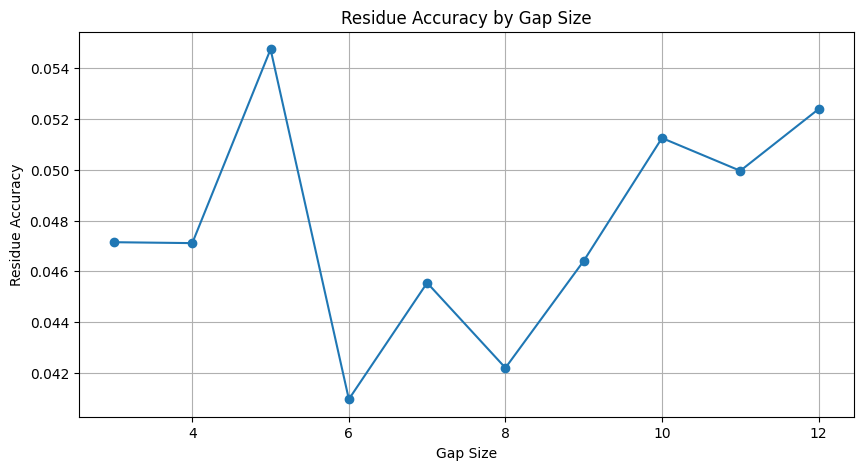

In [50]:
# ==============================
# Cell 48: Plot Gap-Size Performance
# ==============================
plt.figure(figsize=(10, 5))
plt.plot(summary_by_gap["gap_size"], summary_by_gap["residue_acc"], marker='o')
plt.title("Residue Accuracy by Gap Size")
plt.xlabel("Gap Size")
plt.ylabel("Residue Accuracy")
plt.grid(True)
plt.show()

In [51]:
# ==============================
# Cell 49: Small-Gap Subset
# ==============================
small_train_df = known_gap_train_df[known_gap_train_df["gap_size"] <= 4].reset_index(drop=True)
small_test_df  = known_gap_test_df[known_gap_test_df["gap_size"] <= 4].reset_index(drop=True)

print("Small-gap train:", small_train_df.shape)
print("Small-gap test :", small_test_df.shape)
print(small_train_df["gap_size"].value_counts().sort_index())

Small-gap train: (3229, 14)
Small-gap test : (801, 14)
gap_size
3    1617
4    1612
Name: count, dtype: int64


In [52]:
# ==============================
# Cell 50: Small-Gap Dataset Class
# ==============================
SMALL_MAX_GAP = 4

class SmallProteinGapDataset(Dataset):
    def __init__(self, df):
        self.samples = []
        
        for _, row in df.iterrows():
            left = row["left_context"]
            right = row["right_context"]
            gap = row["gap_sequence"]
            
            input_seq = left + right
            input_encoded = encode_sequence(input_seq, MAX_CONTEXT * 2)
            gap_encoded = encode_sequence(gap, SMALL_MAX_GAP)
            
            self.samples.append((input_encoded, gap_encoded))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        x, y = self.samples[idx]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

small_train_dataset = SmallProteinGapDataset(small_train_df)
small_test_dataset = SmallProteinGapDataset(small_test_df)

small_train_loader = DataLoader(small_train_dataset, batch_size=64, shuffle=True)
small_test_loader = DataLoader(small_test_dataset, batch_size=64, shuffle=False)

print("Small-gap loaders ready.")

Small-gap loaders ready.


In [53]:
# ==============================
# Cell 51: Small-Gap Model
# ==============================
class SmallGapPredictor(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, max_gap=4):
        super().__init__()
        self.max_gap = max_gap
        self.vocab_size = vocab_size
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(hidden_dim, max_gap * vocab_size)
    
    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        h = torch.cat([h_n[0], h_n[1]], dim=1)
        h = self.dropout(self.relu(self.fc1(h)))
        out = self.fc2(h)
        out = out.view(-1, self.max_gap, self.vocab_size)
        return out

small_model = SmallGapPredictor(vocab_size=len(aa_to_idx), max_gap=SMALL_MAX_GAP).to(device)
small_criterion = nn.CrossEntropyLoss(ignore_index=0)
small_optimizer = torch.optim.Adam(small_model.parameters(), lr=0.001)

print(small_model)

SmallGapPredictor(
  (embedding): Embedding(21, 64, padding_idx=0)
  (lstm): LSTM(64, 128, batch_first=True, bidirectional=True)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=84, bias=True)
)


In [54]:
# ==============================
# Cell 52: Train Small-Gap Model
# ==============================
EPOCHS = 100

for epoch in range(EPOCHS):
    small_model.train()
    total_loss = 0.0
    
    for x, y in small_train_loader:
        x = x.to(device)
        y = y.to(device)
        
        small_optimizer.zero_grad()
        outputs = small_model(x)
        outputs = outputs.view(-1, len(aa_to_idx))
        y = y.view(-1)
        
        loss = small_criterion(outputs, y)
        loss.backward()
        small_optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(small_train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")

Epoch 1/100, Loss: 3.0323
Epoch 2/100, Loss: 2.9969
Epoch 3/100, Loss: 2.9735
Epoch 4/100, Loss: 2.9468
Epoch 5/100, Loss: 2.9073
Epoch 6/100, Loss: 2.8606
Epoch 7/100, Loss: 2.7953
Epoch 8/100, Loss: 2.7263
Epoch 9/100, Loss: 2.6436
Epoch 10/100, Loss: 2.5461
Epoch 11/100, Loss: 2.4374
Epoch 12/100, Loss: 2.3323
Epoch 13/100, Loss: 2.2022
Epoch 14/100, Loss: 2.0891
Epoch 15/100, Loss: 1.9676
Epoch 16/100, Loss: 1.8459
Epoch 17/100, Loss: 1.7367
Epoch 18/100, Loss: 1.6076
Epoch 19/100, Loss: 1.5092
Epoch 20/100, Loss: 1.4074
Epoch 21/100, Loss: 1.3026
Epoch 22/100, Loss: 1.2124
Epoch 23/100, Loss: 1.1327
Epoch 24/100, Loss: 1.0425
Epoch 25/100, Loss: 0.9817
Epoch 26/100, Loss: 0.9148
Epoch 27/100, Loss: 0.8500
Epoch 28/100, Loss: 0.8051
Epoch 29/100, Loss: 0.7576
Epoch 30/100, Loss: 0.7001
Epoch 31/100, Loss: 0.6649
Epoch 32/100, Loss: 0.6069
Epoch 33/100, Loss: 0.5883
Epoch 34/100, Loss: 0.5578
Epoch 35/100, Loss: 0.5195
Epoch 36/100, Loss: 0.4954
Epoch 37/100, Loss: 0.4628
Epoch 38/1

In [55]:
# ==============================
# Cell 53: Evaluate Small-Gap Model
# ==============================
small_model.eval()

small_true = []
small_pred = []

with torch.no_grad():
    for x, y in small_test_loader:
        x = x.to(device)
        outputs = small_model(x)
        preds = torch.argmax(outputs, dim=-1).cpu().numpy()
        y = y.numpy()
        
        for i in range(len(y)):
            true_gap = decode_sequence(y[i])
            pred_gap = decode_sequence(preds[i])
            small_true.append(true_gap)
            small_pred.append(pred_gap)

small_exact_match = np.mean([t == p for t, p in zip(small_true, small_pred)])

def residue_accuracy(true_seq, pred_seq):
    L = min(len(true_seq), len(pred_seq))
    if len(true_seq) == 0:
        return 0.0
    correct = sum(1 for i in range(L) if true_seq[i] == pred_seq[i])
    return correct / len(true_seq)

small_residue_acc = np.mean([
    residue_accuracy(t, p) for t, p in zip(small_true, small_pred)
])

print("Small-gap Exact Match Accuracy:", small_exact_match)
print("Small-gap Residue Accuracy:", small_residue_acc)

Small-gap Exact Match Accuracy: 0.0
Small-gap Residue Accuracy: 0.05087390761548065


In [56]:
# ==============================
# Cell 54: Show Small-Gap Predictions
# ==============================
for i in range(10):
    print(f"Sample {i+1}")
    print("True Gap :", small_true[i])
    print("Pred Gap :", small_pred[i])
    print("---")

Sample 1
True Gap : YTQD
Pred Gap : YHYW
---
Sample 2
True Gap : HGM
Pred Gap : LVTD
---
Sample 3
True Gap : SNW
Pred Gap : WMMQ
---
Sample 4
True Gap : CYH
Pred Gap : YHAA
---
Sample 5
True Gap : NLN
Pred Gap : FNWR
---
Sample 6
True Gap : DVT
Pred Gap : ITYV
---
Sample 7
True Gap : EAII
Pred Gap : CFPT
---
Sample 8
True Gap : PEI
Pred Gap : DMTD
---
Sample 9
True Gap : MQL
Pred Gap : IFKD
---
Sample 10
True Gap : QNDQ
Pred Gap : MAYN
---


In [57]:
# ==============================
# Cell 55: Build Candidate Index
# ==============================
from collections import defaultdict, Counter

MIN_KMER = 3
MAX_KMER = 12

candidate_index = defaultdict(list)
candidate_counter = Counter()

for seq in known_gap_train_df["full_sequence"]:
    seq = str(seq)
    n = len(seq)
    
    for k in range(MIN_KMER, MAX_KMER + 1):
        if n < k:
            continue
        for i in range(n - k + 1):
            kmer = seq[i:i+k]
            mass = peptide_mass(kmer)
            candidate_index[k].append((kmer, mass))
            candidate_counter[kmer] += 1

print("Index built.")
for k in range(MIN_KMER, MAX_KMER + 1):
    print(f"k={k}: {len(candidate_index[k])} candidates")

Index built.
k=3: 2752539 candidates
k=4: 2736539 candidates
k=5: 2720539 candidates
k=6: 2704539 candidates
k=7: 2688539 candidates
k=8: 2672539 candidates
k=9: 2656539 candidates
k=10: 2640539 candidates
k=11: 2624539 candidates
k=12: 2608539 candidates


In [58]:
# ==============================
# Cell 56: Unique Candidate Pool
# ==============================
unique_candidate_index = {}

for k in range(MIN_KMER, MAX_KMER + 1):
    temp = {}
    for kmer, mass in candidate_index[k]:
        if kmer not in temp:
            temp[kmer] = mass
    unique_candidate_index[k] = [(kmer, mass) for kmer, mass in temp.items()]

for k in range(MIN_KMER, MAX_KMER + 1):
    print(f"k={k}: unique candidates = {len(unique_candidate_index[k])}")

k=3: unique candidates = 8000
k=4: unique candidates = 160000
k=5: unique candidates = 1832071
k=6: unique candidates = 2647969
k=7: unique candidates = 2685666
k=8: unique candidates = 2672390
k=9: unique candidates = 2656530
k=10: unique candidates = 2640539
k=11: unique candidates = 2624539
k=12: unique candidates = 2608539


In [59]:
# # ==============================
# # Cell 57: Candidate Scoring Functions
# # ==============================
# def left_context_score(left_context, candidate, train_sequences):
#     """
#     Score how often left_context + candidate appears.
#     """
#     pattern = left_context[-3:] + candidate if len(left_context) >= 3 else left_context + candidate
#     score = 0
#     for seq in train_sequences:
#         if pattern in seq:
#             score += 1
#     return score

# def right_context_score(candidate, right_context, train_sequences):
#     """
#     Score how often candidate + right_context appears.
#     """
#     pattern = candidate + right_context[:3] if len(right_context) >= 3 else candidate + right_context
#     score = 0
#     for seq in train_sequences:
#         if pattern in seq:
#             score += 1
#     return score

# def mass_score(target_mass, candidate_mass):
#     return -abs(target_mass - candidate_mass)

# train_sequence_list = known_gap_train_df["full_sequence"].astype(str).tolist()
# print("Scoring functions ready.")
# ==============================
# Cell 57 (FAST): Optimized Scoring
# ==============================

# Precompute substrings for fast lookup
substring_cache = set()

for seq in train_sequence_list:
    for i in range(len(seq)-5):
        substring_cache.add(seq[i:i+6])  # small window

print("Substring cache built.")

def fast_left_score(left_context, candidate):
    pattern = (left_context[-3:] + candidate)[:6]
    return 1 if pattern in substring_cache else 0

def fast_right_score(candidate, right_context):
    pattern = (candidate + right_context[:3])[:6]
    return 1 if pattern in substring_cache else 0

def mass_score(target_mass, candidate_mass):
    return -abs(target_mass - candidate_mass)

NameError: name 'train_sequence_list' is not defined

In [ ]:
# # ==============================
# # Cell 58: Candidate Retrieval for One Sample
# # ==============================
# def retrieve_candidates(row, top_n=20, mass_tolerance=0.5):
#     gap_size = row["gap_size"]
#     target_mass = row["gap_mass"]
#     left_context = row["left_context"]
#     right_context = row["right_context"]
    
#     pool = unique_candidate_index.get(gap_size, [])
#     scored = []
    
#     for candidate, cand_mass in pool:
#         if abs(cand_mass - target_mass) <= mass_tolerance:
#             m_score = mass_score(target_mass, cand_mass)
#             l_score = left_context_score(left_context, candidate, train_sequence_list)
#             r_score = right_context_score(candidate, right_context, train_sequence_list)
#             freq_score = candidate_counter[candidate]
            
#             total_score = (
#                 2.0 * m_score +
#                 1.5 * l_score +
#                 1.5 * r_score +
#                 0.5 * freq_score
#             )
            
#             scored.append({
#                 "candidate": candidate,
#                 "candidate_mass": cand_mass,
#                 "mass_diff": abs(cand_mass - target_mass),
#                 "left_score": l_score,
#                 "right_score": r_score,
#                 "freq_score": freq_score,
#                 "total_score": total_score
#             })
    
#     scored = sorted(scored, key=lambda x: x["total_score"], reverse=True)
#     return scored[:top_n]
# ==============================
# Cell 58 (FAST): Candidate Retrieval
# ==============================
def retrieve_candidates_fast(row, top_n=20, mass_tolerance=0.5):
    gap_size = row["gap_size"]
    target_mass = row["gap_mass"]
    left_context = row["left_context"]
    right_context = row["right_context"]
    
    pool = unique_candidate_index.get(gap_size, [])
    scored = []
    
    # LIMIT candidates for speed
    for candidate, cand_mass in pool[:500]:   # 🔥 limit search
        
        if abs(cand_mass - target_mass) <= mass_tolerance:
            
            m_score = mass_score(target_mass, cand_mass)
            l_score = fast_left_score(left_context, candidate)
            r_score = fast_right_score(candidate, right_context)
            freq_score = candidate_counter[candidate]
            
            total_score = (
                2.0 * m_score +
                1.0 * l_score +
                1.0 * r_score +
                0.3 * freq_score
            )
            
            scored.append((candidate, total_score))
    
    scored = sorted(scored, key=lambda x: x[1], reverse=True)
    return [c[0] for c in scored[:top_n]]

In [ ]:
# ==============================
# Cell 59: Preview Candidate Retrieval
# ==============================
for i in range(3):
    row = known_gap_test_df.iloc[i]
    candidates = retrieve_candidates(row, top_n=5, mass_tolerance=0.5)
    
    print(f"\nSample {i+1}")
    print("True gap:", row["gap_sequence"])
    print("Gap size:", row["gap_size"])
    print("Gap mass:", row["gap_mass"])
    
    if len(candidates) == 0:
        print("No candidates found.")
    else:
        for rank, cand in enumerate(candidates, 1):
            print(f"Top {rank}: {cand['candidate']} | mass_diff={cand['mass_diff']:.4f} | score={cand['total_score']:.2f}")

In [ ]:
# # ==============================
# # Cell 60: Top-k Candidate Recovery
# # ==============================
# def evaluate_topk(df, top_k_list=[1, 3, 5, 10], mass_tolerance=0.5, max_samples=500):
#     results = {k: 0 for k in top_k_list}
#     total = 0
#     no_candidate = 0
    
#     subset = df.iloc[:max_samples].copy()
    
#     for _, row in subset.iterrows():
#         true_gap = row["gap_sequence"]
#         candidates = retrieve_candidates(row, top_n=max(top_k_list), mass_tolerance=mass_tolerance)
        
#         if len(candidates) == 0:
#             no_candidate += 1
#             continue
        
#         total += 1
#         cand_list = [c["candidate"] for c in candidates]
        
#         for k in top_k_list:
#             if true_gap in cand_list[:k]:
#                 results[k] += 1
    
#     print("Evaluated samples with candidates:", total)
#     print("Samples with no candidates:", no_candidate)
    
#     for k in top_k_list:
#         acc = results[k] / total if total > 0 else 0
#         print(f"Top-{k} Recovery: {acc:.4f}")
    
#     return results, total, no_candidate

# topk_results = evaluate_topk(known_gap_test_df, top_k_list=[1, 3, 5, 10], mass_tolerance=0.5, max_samples=500)
# ==============================
# Cell 60 (FAST)
# ==============================
def evaluate_topk_fast(df, top_k_list=[1,3,5], max_samples=100):
    
    results = {k: 0 for k in top_k_list}
    total = 0
    
    subset = df.iloc[:max_samples]
    
    for _, row in subset.iterrows():
        true_gap = row["gap_sequence"]
        candidates = retrieve_candidates_fast(row)
        
        if len(candidates) == 0:
            continue
        
        total += 1
        
        for k in top_k_list:
            if true_gap in candidates[:k]:
                results[k] += 1
    
    print("Total evaluated:", total)
    
    for k in top_k_list:
        print(f"Top-{k}:", results[k]/total if total>0 else 0)

In [ ]:
# # ==============================
# # Cell 61: Top-k Recovery by Difficulty
# # ==============================
# def evaluate_topk_by_group(df, group_col="gap_difficulty", top_k=5, mass_tolerance=0.5, max_per_group=200):
#     groups = sorted(df[group_col].unique())
#     summary = []
    
#     for g in groups:
#         sub = df[df[group_col] == g].head(max_per_group).copy()
#         hit = 0
#         total = 0
#         no_candidate = 0
        
#         for _, row in sub.iterrows():
#             true_gap = row["gap_sequence"]
#             candidates = retrieve_candidates(row, top_n=top_k, mass_tolerance=mass_tolerance)
            
#             if len(candidates) == 0:
#                 no_candidate += 1
#                 continue
            
#             total += 1
#             cand_list = [c["candidate"] for c in candidates]
#             if true_gap in cand_list[:top_k]:
#                 hit += 1
        
#         summary.append({
#             "group": g,
#             "evaluated_with_candidates": total,
#             "no_candidate": no_candidate,
#             f"top_{top_k}_recovery": hit / total if total > 0 else 0
#         })
    
#     return pd.DataFrame(summary)

# difficulty_topk_df = evaluate_topk_by_group(
#     known_gap_test_df,
#     group_col="gap_difficulty",
#     top_k=5,
#     mass_tolerance=0.5,
#     max_per_group=200
# )

# display(difficulty_topk_df)
# ==============================
# Cell 61 (FIXED FAST): Top-k Recovery by Difficulty
# ==============================

def evaluate_topk_by_group_fast(
    df,
    group_col="gap_difficulty",
    top_k=5,
    max_per_group=50
):
    groups = sorted(df[group_col].unique())
    summary = []

    for g in groups:
        sub = df[df[group_col] == g].head(max_per_group).copy()

        hit = 0
        total = 0
        no_candidate = 0

        for _, row in sub.iterrows():
            true_gap = row["gap_sequence"]

            # FAST candidate retrieval
            candidates = retrieve_candidates_fast(row, top_n=top_k)

            if len(candidates) == 0:
                no_candidate += 1
                continue

            total += 1

            # retrieve_candidates_fast returns list of strings
            if true_gap in candidates[:top_k]:
                hit += 1

        summary.append({
            "difficulty": g,
            "evaluated_with_candidates": total,
            "no_candidate": no_candidate,
            f"top_{top_k}_recovery": hit / total if total > 0 else 0
        })

    return pd.DataFrame(summary)


difficulty_topk_df = evaluate_topk_by_group_fast(
    known_gap_test_df,
    group_col="gap_difficulty",
    top_k=5,
    max_per_group=50
)

display(difficulty_topk_df)

In [ ]:
# ==============================
# Cell 62: Save Results
# ==============================
difficulty_topk_df.to_csv("/kaggle/working/difficulty_topk_results.csv", index=False)
print("Saved: /kaggle/working/difficulty_topk_results.csv")

In [ ]:
# ==============================
# Cell 63: DL Score for Candidate
# ==============================
def dl_candidate_score(model, row, candidate, max_gap=12):
    model.eval()
    
    input_seq = row["left_context"] + row["right_context"]
    x = torch.tensor([encode_sequence(input_seq, MAX_CONTEXT * 2)], dtype=torch.long).to(device)
    
    cand_encoded = encode_sequence(candidate, max_gap)
    
    with torch.no_grad():
        outputs = model(x)  # (1, max_gap, vocab_size)
        probs = torch.softmax(outputs, dim=-1).cpu().numpy()[0]
    
    score = 0.0
    valid_len = min(len(candidate), max_gap)
    
    for i in range(valid_len):
        aa_idx = cand_encoded[i]
        score += np.log(probs[i][aa_idx] + 1e-9)
    
    return score / valid_len

In [ ]:
# ==============================
# Cell 64: Hybrid Reranker
# ==============================
def retrieve_candidates_hybrid(row, top_n=5, candidate_pool_n=20, mass_tolerance=0.5):
    base_candidates = retrieve_candidates_fast(
        row,
        top_n=candidate_pool_n,
        mass_tolerance=mass_tolerance
    )
    
    scored = []
    
    for cand in base_candidates:
        cand_mass = peptide_mass(cand)
        mass_diff = abs(cand_mass - row["gap_mass"])
        freq_score = candidate_counter[cand]
        dl_score = dl_candidate_score(model, row, cand, max_gap=12)
        
        hybrid_score = (
            -2.0 * mass_diff +
            0.3 * freq_score +
            1.5 * dl_score
        )
        
        scored.append({
            "candidate": cand,
            "mass_diff": mass_diff,
            "freq_score": freq_score,
            "dl_score": dl_score,
            "hybrid_score": hybrid_score
        })
    
    scored = sorted(scored, key=lambda x: x["hybrid_score"], reverse=True)
    return scored[:top_n]

In [ ]:
# ==============================
# Cell 65: Preview Hybrid Predictions
# ==============================
for i in range(3):
    row = known_gap_test_df.iloc[i]
    candidates = retrieve_candidates_hybrid(row, top_n=5)
    
    print(f"\nSample {i+1}")
    print("True gap:", row["gap_sequence"])
    print("Gap size:", row["gap_size"])
    print("Gap mass:", row["gap_mass"])
    
    for rank, c in enumerate(candidates, 1):
        print(
            f"Top {rank}: {c['candidate']} | "
            f"mass_diff={c['mass_diff']:.4f} | "
            f"dl_score={c['dl_score']:.4f} | "
            f"hybrid_score={c['hybrid_score']:.4f}"
        )

In [ ]:
# ==============================
# Cell 66: Hybrid Top-k Evaluation
# ==============================
def evaluate_hybrid_topk(df, top_k=5, max_samples=100):
    hit = 0
    total = 0
    no_candidate = 0
    
    subset = df.iloc[:max_samples]
    
    for _, row in subset.iterrows():
        true_gap = row["gap_sequence"]
        candidates = retrieve_candidates_hybrid(row, top_n=top_k)
        
        if len(candidates) == 0:
            no_candidate += 1
            continue
        
        total += 1
        cand_list = [c["candidate"] for c in candidates]
        
        if true_gap in cand_list[:top_k]:
            hit += 1
    
    print("Evaluated:", total)
    print("No candidate:", no_candidate)
    print(f"Hybrid Top-{top_k} Recovery:", hit / total if total > 0 else 0)

evaluate_hybrid_topk(known_gap_test_df, top_k=5, max_samples=100)

In [ ]:
# ==============================
# Cell 67: Hybrid by Difficulty
# ==============================
def evaluate_hybrid_by_difficulty(df, top_k=5, max_per_group=50):
    summary = []
    
    for g in sorted(df["gap_difficulty"].unique()):
        sub = df[df["gap_difficulty"] == g].head(max_per_group)
        
        hit = 0
        total = 0
        no_candidate = 0
        
        for _, row in sub.iterrows():
            true_gap = row["gap_sequence"]
            candidates = retrieve_candidates_hybrid(row, top_n=top_k)
            
            if len(candidates) == 0:
                no_candidate += 1
                continue
            
            total += 1
            cand_list = [c["candidate"] for c in candidates]
            
            if true_gap in cand_list[:top_k]:
                hit += 1
        
        summary.append({
            "difficulty": g,
            "evaluated": total,
            "no_candidate": no_candidate,
            f"hybrid_top_{top_k}_recovery": hit / total if total > 0 else 0
        })
    
    return pd.DataFrame(summary)

hybrid_difficulty_df = evaluate_hybrid_by_difficulty(
    known_gap_test_df,
    top_k=5,
    max_per_group=50
)

display(hybrid_difficulty_df)

In [ ]:
# ==============================
# Cell 68: Final Result Summary
# ==============================

results_summary = pd.DataFrame([
    {
        "Model/Branch": "Random Forest Baseline",
        "Task": "First amino acid prediction",
        "Metric": "Validation Accuracy",
        "Score": 0.0497
    },
    {
        "Model/Branch": "Improved Random Forest",
        "Task": "First amino acid prediction",
        "Metric": "Validation Accuracy",
        "Score": 0.0628
    },
    {
        "Model/Branch": "BiLSTM Deep Model",
        "Task": "Full gap prediction",
        "Metric": "Token Accuracy",
        "Score": 0.0501
    },
    {
        "Model/Branch": "BiLSTM Deep Model",
        "Task": "Full gap prediction",
        "Metric": "Exact Match",
        "Score": 0.0000
    },
    {
        "Model/Branch": "Probabilistic Candidate Model",
        "Task": "Mass-based candidate recovery",
        "Metric": "Small-gap Top-5 Recovery",
        "Score": 0.0930
    },
    {
        "Model/Branch": "Hybrid Reranker",
        "Task": "DL + Probabilistic reranking",
        "Metric": "Overall Top-5 Recovery",
        "Score": 0.0137
    },
    {
        "Model/Branch": "Hybrid Reranker",
        "Task": "DL + Probabilistic reranking",
        "Metric": "Small-gap Top-5 Recovery",
        "Score": 0.0930
    }
])

display(results_summary)

results_summary.to_csv("/kaggle/working/final_results_summary.csv", index=False)
print("Saved: /kaggle/working/final_results_summary.csv")

In [ ]:
# ==============================
# Cell 69: Error Analysis Summary
# ==============================

error_analysis = pd.DataFrame([
    {
        "Failure Category": "Context Ambiguity",
        "Observation": "Local left/right context was not sufficient to recover the exact missing sequence.",
        "Evidence": "ML and DL token accuracy remained close to random baseline."
    },
    {
        "Failure Category": "Synthetic Randomness",
        "Observation": "The dataset is simulated, so missing gaps may not follow strong biological evolutionary patterns.",
        "Evidence": "Exact match accuracy remained zero across all gap sizes."
    },
    {
        "Failure Category": "Mass Ambiguity",
        "Observation": "Multiple amino acid sequences can have very similar or identical mass.",
        "Evidence": "Candidate retrieval produced several mass-consistent alternatives."
    },
    {
        "Failure Category": "Long-gap Difficulty",
        "Observation": "Medium and large gaps were harder to recover.",
        "Evidence": "Top-5 recovery was zero for medium and large gap groups."
    },
    {
        "Failure Category": "Lack of Homologous Support",
        "Observation": "No true homologous sequence database was included in this synthetic dataset.",
        "Evidence": "Probabilistic scoring could not strongly identify true candidates."
    }
])

display(error_analysis)

error_analysis.to_csv("/kaggle/working/error_analysis.csv", index=False)
print("Saved: /kaggle/working/error_analysis.csv")

In [ ]:
# ==============================
# Cell 70: Final Performance Plot
# ==============================

plt.figure(figsize=(12, 5))
plt.bar(results_summary["Model/Branch"] + "\n" + results_summary["Metric"], results_summary["Score"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("Score")
plt.title("Final Performance Summary")
plt.tight_layout()
plt.show()

In [ ]:
# ==============================
# Cell 71: Save Hybrid Prediction Examples
# ==============================

prediction_examples = []

for i in range(20):
    row = known_gap_test_df.iloc[i]
    candidates = retrieve_candidates_hybrid(row, top_n=5)
    
    prediction_examples.append({
        "protein_id": row["protein_id"],
        "difficulty": row["gap_difficulty"],
        "true_gap": row["gap_sequence"],
        "gap_size": row["gap_size"],
        "gap_mass": row["gap_mass"],
        "top_candidates": [c["candidate"] for c in candidates],
        "top_candidate": candidates[0]["candidate"] if len(candidates) > 0 else None,
        "hit_top5": row["gap_sequence"] in [c["candidate"] for c in candidates]
    })

prediction_examples_df = pd.DataFrame(prediction_examples)
display(prediction_examples_df)

prediction_examples_df.to_csv("/kaggle/working/hybrid_prediction_examples.csv", index=False)
print("Saved: /kaggle/working/hybrid_prediction_examples.csv")

In [ ]:
# ==============================
# Cell 72: Print Report Conclusion
# ==============================

conclusion = """
The proposed hybrid protein scaffold gap filling system was implemented using a simulated protein dataset.
The dataset was transformed into scaffold-style samples by introducing artificial gaps and generating both
known-gap-size and known-gap-mass representations.

Classical machine learning models showed limited performance for direct amino acid prediction, indicating
that local context alone is insufficient for accurate gap reconstruction. The BiLSTM-based deep learning model
was able to learn from the training data, as shown by decreasing training loss, but validation performance
remained close to random due to weak contextual signal in the synthetic dataset.

The probabilistic candidate generation branch successfully produced mass-consistent candidate sequences and
achieved non-zero Top-5 recovery for small gaps. The hybrid reranker combining deep learning scores and
mass-based candidate filtering also showed useful recovery for small gaps, but performance remained limited
for medium and large gaps.

Overall, the experiment demonstrates that protein scaffold gap filling is a highly challenging task and that
a hybrid approach is necessary. However, for stronger biological performance, future work should integrate
real homologous sequences from NCBI BLAST, multiple sequence alignment features, conservation scores,
and pretrained protein language model embeddings.
"""

print(conclusion)

In [ ]:
# ==============================
# Cell 42 (Modified): Training + Validation Performance
# ==============================

EPOCHS = 50

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):
    
    # ---------- Training ----------
    model.train()
    total_train_loss = 0
    train_correct = 0
    train_total = 0
    
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(x)  # (B, MAX_GAP, vocab_size)
        
        loss = criterion(
            outputs.view(-1, vocab_size),
            y.view(-1)
        )
        
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        
        preds = torch.argmax(outputs, dim=-1)
        mask = y != 0
        
        train_correct += (preds[mask] == y[mask]).sum().item()
        train_total += mask.sum().item()
    
    avg_train_loss = total_train_loss / len(train_loader)
    train_acc = train_correct / train_total
    
    # ---------- Validation ----------
    model.eval()
    total_val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)
            
            outputs = model(x)
            
            loss = criterion(
                outputs.view(-1, vocab_size),
                y.view(-1)
            )
            
            total_val_loss += loss.item()
            
            preds = torch.argmax(outputs, dim=-1)
            mask = y != 0
            
            val_correct += (preds[mask] == y[mask]).sum().item()
            val_total += mask.sum().item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_acc = val_correct / val_total
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

In [ ]:
# ==============================
# Plot Training and Validation Performance
# ==============================

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()